In [77]:
import torch
import torch.nn as nn

import torchvision.transforms as transforms
from torchvision import datasets
from torch.utils.data import DataLoader, SubsetRandomSampler

import numpy as np
import matplotlib.pyplot as plt

import scienceplots
plt.style.use(['science','notebook','grid'])

import numpy as np
from torchvision.models.feature_extraction import get_graph_node_names, create_feature_extractor

In [78]:
from models.models import LeNet5
from visualization.filters import display_collapsed_filters

In [79]:
my_local_data = '/mnt/g/My Drive/types/'

In [80]:
ToTensorAndNormalize = transforms.Compose(
    [
    transforms.Resize((244,244)),
    # transforms.RandomHorizontalFlip(),
    # transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],  # mean
                         [0.5, 0.5, 0.5] # std
                         )
    ]
)
aux_data = datasets.ImageFolder(
    root=my_local_data,
    transform=ToTensorAndNormalize
)

In [81]:
class_indices = aux_data.class_to_idx
# Original names and their order which you know
names_dict = {'typeA': 'Diameter\nFluctuations',
              'typeB': 'Node Cut',
              'typeC': 'Particle Hit',
              'goodIngots': 'No Structure\nLoss'
              }

# Get class indices from the ImageFolder
class_indices = aux_data.class_to_idx

# Order your names list according to the class indices
ordered_names = [names_dict[class_name] for class_name, index in sorted(class_indices.items(), key=lambda item: item[1])]


In [82]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = LeNet5()
model = model.to(device=device)
batch_size = 16

In [83]:
# Determine the layer from which to extract features --> we want to extract at the pooling layers
layers = ["convStack.1", "convStack.3"]
node_names = get_graph_node_names(model)
feature_extractor = create_feature_extractor(model, layers)

In [84]:
loader = DataLoader(
    dataset=aux_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=8
)

In [85]:
features = {layer_name: [] for layer_name in layers}
labels = []

feature_extractor.eval()
with torch.no_grad():
    for data in loader:
        image, label = data[0].to(device), data[1].to(device)
        predicted_dict = feature_extractor(image)
        for layer_name in layers:
            features[layer_name].extend(predicted_dict[layer_name].cpu().numpy())
        labels.extend(label.cpu().numpy())

In [86]:
pooling_layers = ['Pooling layer 1', 'Pooling layer 2']

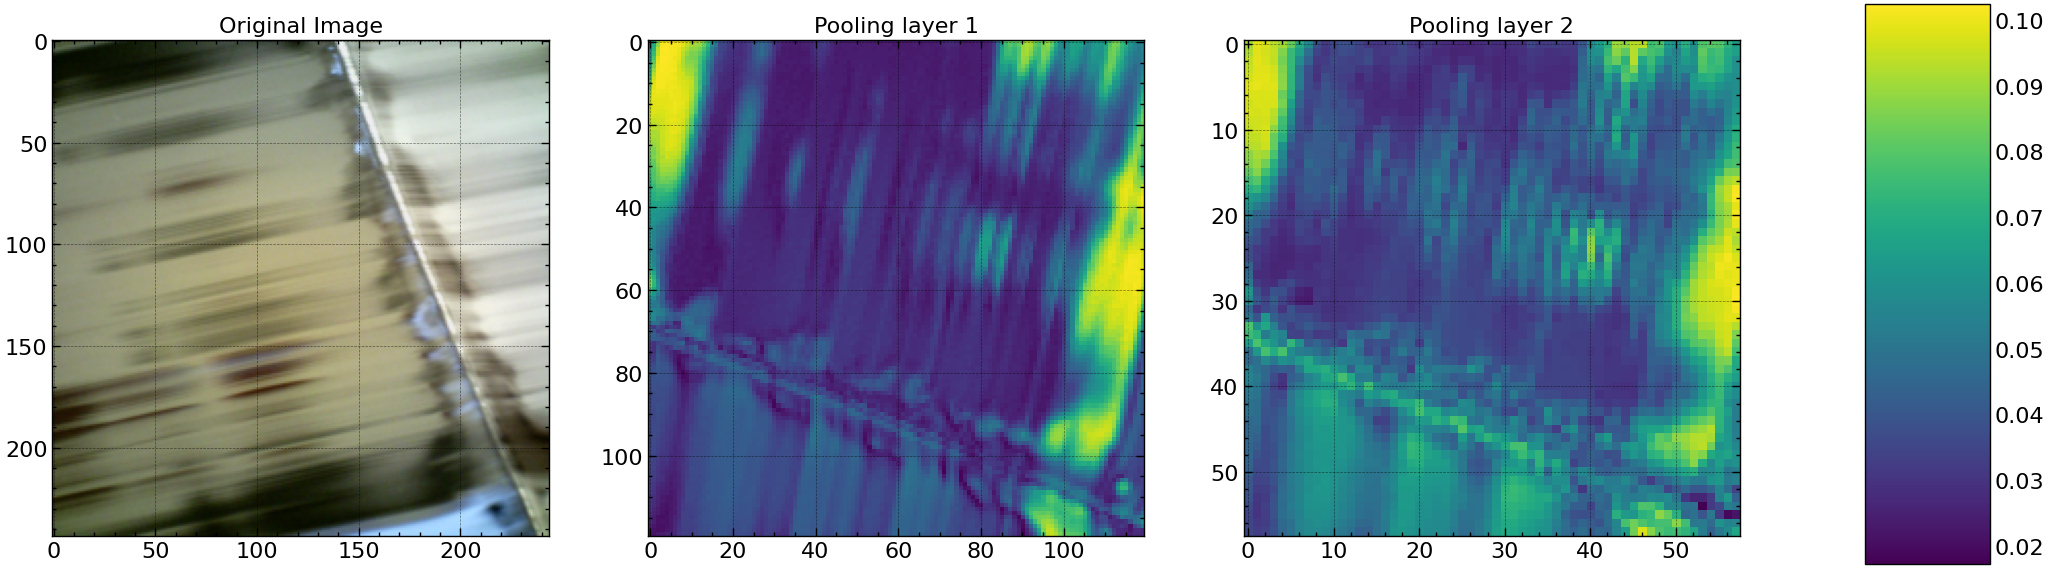

In [87]:
display_collapsed_filters(features=features, img_num=156, layers=layers, cmap='viridis', data=aux_data, name_layers=pooling_layers)